In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
!pip install stable-baselines3[extra] protobuf==3.20.*

In [ ]:
!pip install mss pydirectinput pytesseract

In [ ]:
!pip install gym

In [ ]:
!pip install pillow

In [1]:
from mss import mss
import pydirectinput
import cv2
import numpy as np
import pytesseract
from matplotlib import pyplot as plt
import time
import gymnasium as gym
from gymnasium.spaces import Discrete, Box


In [ ]:
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

Create Environment

In [ ]:
class WebGame(gym.Env):
    def __init__(self):
        super().__init__()
        self.observation_space = Box(low=0, high=255, shape=(1, 83, 100), dtype=np.uint8)
        self.action_space = Discrete(3)
        self.cap = mss()

        self.game_location = {'top': 300, 'left': 0, 'width': 700, 'height': 500}

        self.game_over_location = {'top': 350, 'left': 580, 'width': 20, 'height': 10} 

    def step(self, action):
        # Action mapping
        action_map = {
            0: 'space',  # Jump action
            1: 'down',   # Duck action
            2: 'no_op'   # No operation (inaction)
        }

        if action != 2:
            pydirectinput.press(action_map[action])

        done, done_cap = self.get_done()

        observation = self.get_observation()

        reward = -1
        if action == 2:
            reward = 2

        info = {}
        return observation, reward, done, done_cap, info

    def reset(self, seed=None, options=None):
        time.sleep(1)
        pydirectinput.click(x=150, y=150)
        pydirectinput.press('space')
        return self.get_observation(), {}

    def render(self):
        cv2.imshow('Game', np.array(self.cap.grab(self.game_location))[:, :, :3])
        if cv2.waitKey(1) & 0xFF == ord('q'):
            self.close()

    def close(self):
        cv2.destroyAllWindows()

    def get_observation(self):
        # Capture game screen, convert to grayscale, resize, and reshape the observation
        raw = np.array(self.cap.grab(self.game_location))[:, :, :3]
        gray = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, (100, 83))
        channel = np.reshape(resized, (1, 83, 100))
        return channel

    def get_done(self):
        # Check for color change at a specific location to detect game over state
        done_cap = np.array(self.cap.grab(self.game_over_location))
        
        pixel_value = done_cap[5, 5, :3]
        temp = False
        done = True
        tolerance = 30
        
        if np.all(np.abs(pixel_value - np.array([255, 255, 255])) < tolerance): 
            done = False
        
        return done, temp

In [97]:
env = WebGame()

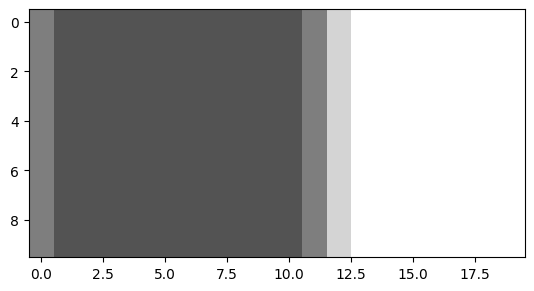

In [93]:
done, ok = env.get_done()
plt.imshow(done, cmap='gray')

In [94]:
ok

True

In [98]:
for episode in range(10): 
    obs = env.reset()
    done = False  
    total_reward   = 0
    while not done: 
        obs, reward, done, temp, info =  env.step(env.action_space.sample())
        total_reward  += reward
    print(f'Total Reward for episode {episode} is {total_reward}')

Total Reward for episode 0 is -7
Total Reward for episode 1 is -3
Total Reward for episode 2 is -4
Total Reward for episode 3 is -4
Total Reward for episode 4 is 2
Total Reward for episode 5 is -3
Total Reward for episode 6 is -4
Total Reward for episode 7 is 1
Total Reward for episode 8 is 10
Total Reward for episode 9 is 1


In [99]:
import os
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common import env_checker 

In [35]:
env = WebGame()

In [26]:
env_checker.check_env(env)

In [101]:
class TrainAndLoggingCallback(BaseCallback):

    def __init__ (self, check_freq, save_path, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, 'best_model_{}'.format(self.n_calls))
            self.model.save(model_path)

        return True

In [108]:
CHECKPOINT_DIR = './opttrain/'
LOG_DIR = './optlogs/'

In [109]:
callback = TrainAndLoggingCallback(check_freq=5000, save_path=CHECKPOINT_DIR)

In [110]:
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

In [111]:
model = DQN("CnnPolicy", env, tensorboard_log=LOG_DIR, verbose=1 , buffer_size=50000, learning_starts=5000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [112]:
model.learn(total_timesteps=50000, callback=callback)

Logging to ./optlogs/DQN_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 16.2     |
|    ep_rew_mean      | 1        |
|    exploration_rate | 0.988    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2        |
|    time_elapsed     | 23       |
|    total_timesteps  | 65       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 18.8     |
|    ep_rew_mean      | 2.62     |
|    exploration_rate | 0.972    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 3        |
|    time_elapsed     | 48       |
|    total_timesteps  | 150      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 20.2     |
|    ep_rew_mean      | 2.58     |
|    exploration_rate | 0.954    |
| time/               |     

KeyboardInterrupt: 